En una planta automotriz, las fallas imprevistas en las prensas hidráulicas críticas generan detenciones en la línea que cuestan miles de dólares por minuto. El departamento de Mantenimiento y
Confiabilidad ha instrumentado una de las máquinas principales para capturar métricas clave.El dataset contiene 1,000 registros históricos y ha sido perfectamente balanceado (500 casos estables y 500 eventos de fallo crítico) para estructurar un modelo predictivo base sin sesgo inicial de clase. A continuación, la siguiente tabla muestra las variables registradas (pestaña Clasificación Mantenimiento).

a) Entrene un modelo XGBoost realizando una validación cruzada con K = 5. Justifique la elección de hiper-parámetros.

b) Extraiga y documente el promedio y la desviación estándar de las siguientes métricas evaluadas a través de las 5 iteraciones: Accuracy, Precision, Recall y F1-Score.

c) Interpretación Industrial Relativa: Si bien el dataset es balanceado para este entrenamiento, en la operación real de la planta las fallas corresponden a menos del 2% del tiempo total. Explique de forma crítica por qué una métrica de Exactitud alta no es suficiente en entornos productivos industriales reales. Asimismo, determine fundadamente en qué métrica específica debe enfocarse el líder de planta si su prioridad estratégica es minimizar los paros no programados (evitar Falsos Negativos), asumiendo el costo menor de inspeccionar falsas alarmas.

## **a) Entrene un modelo XGBoost realizando una validación cruzada con K = 5. Justifique la elección de hiperparámetros.**

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import openpyxl 
from sklearn import metrics
import xgboost as xgb


ruta_exel = r'C:\Users\Vanhertz\Downloads\datasets_evaluacion3.xlsx'
datos = pd.read_excel(ruta_exel,sheet_name=0, header=0)                 #recordar que el conteo en python comienza desde 0, por lo que la primera hoja es 0, la segunda es 1 y así sucesivamente
datos.describe()


,temperatura_celsius,vibracion_mms,presion_hidraulica_psi,horas_desde_mantenimiento,eficiencia_termica_pct,estado_critico
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,80.534679,3.331176,31.543628,581.218000,88.241583,0.50000
std,10.119508,1.564654,7.589883,441.580593,8.094319,0.50025
min,59.183184,0.956090,13.368095,30.000000,74.029071,0.00000
25%,71.549018,1.910023,24.677467,172.000000,80.410127,0.00000
50%,79.374305,2.757684,33.261955,459.000000,90.493717,0.50000
75%,89.669757,4.721504,38.451356,997.000000,95.659662,1.00000
max,106.304552,8.137302,43.663535,1399.000000,98.488015,1.00000


**Crear y hacer splitting de X e Y**

In [4]:
#crear X,Y
X = datos.iloc[:, [0,1,2,4]].values # se sacan los enteros pues solo podemos usar variables continuas
y = datos.iloc[:, 5].values

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.30,stratify=y,random_state=1) 
#siempre lo mismo como en las otras clases.
#para crear conjuntos de entrenamiento y prueba
#X

In [5]:
#entrenamos el modelo con XGBoost usando make pipe
from sklearn.pipeline import make_pipeline               #es necesario para hacer un pipeline, que es una forma de concatenar proceso
pipe_xgb = make_pipeline(StandardScaler(), xgb.XGBClassifier(n_estimators=3, max_depth=3, learning_rate=0.1, objective='binary:logistic'))
pipe_xgb.fit(X_train, y_train)      #con esto entrenamos el modelo con los datos de entrenamiento

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('xgbclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


**Por que estos hiper-parametros?**

N-stimators

al crear el pipeline por error utilizamos la regresion lineal que... afortunadamente dio como resultado una separacion lineal, eso quiere decir que el modelo "xgb" no necesitaria tanto entrenamiento para encontrar una solucion de clasificacion "linealmente separable" pues busca una solucion no lineal, pero al existir una llegara a eso, de cualquier forma usamos 3 para un learning rate de 0.1, que es algo que se recomienda por lo que aporta el learningrate junto a nstimators para una solucion final

Max-deph

en este caso podemos usar un valor deep bajo para solucion rapida, minetras mas grande este valor mas "preguntas" hay por nodo, es decir retiene menos informacion y evita el overfitting si el valor es bajo

learning rate

la cantidad de peso que tiene cada árbol en la prediccion final, mas grande se demora menos pero puede pasarse del valor optimo y hacer underfitting, asi debemos encontrar un balance entre learning rate y n stimated por eso usamos 0.1, no solo por las clases sino que lo recomiendan el la documentacion

objective='binary:logistic'

es obvio el porque, literal tenemos en la pagina que se nos pide solo datos que corresponden a 2 etiquetas de grupo, eso quiere decir que hay solo 2 variables de categorizacion (clasificacion)
el modelo calcula internamente una curva logística, en lugar de dar un número cualquiera, la salida del modelo estará acotada estrictamente entre 0.0 y 1.0. dando una probabilidad para el dato que se encuentra el grupo en cuestion

## **b) Extraiga y documente el promedio y la desviación estándar de las siguientes métricas evaluadas a través de las 5 iteraciones: Accuracy, Precision, Recall y F1-Score.**

In [6]:
# Validacion cruzada StratifiedKFold
#se tiene que estandarizar porque los valores de las variables son muy diferentes, es para que no tengan un peso mayor en el modelo
#valores entre 59 y 106 en grados y 0.09 a 8.13 en vibracion, si o si hay que estandarizar.
#en este caso por comodidad usamos los codigos de la clase 18 para crear un pipeline
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.model_selection import StratifiedKFold       

kfold = StratifiedKFold(n_splits=5).split(X_train, y_train)
model_xgb = xgb.XGBClassifier(n_estimators=2, max_depth=3, learning_rate=0.01, objective='binary:logistic')

#scores = []
acc_scores, prec_scores, rec_scores, f1_scores = [], [], [], []
for k, (train, test) in enumerate(kfold):
    pipe_temp = make_pipeline(StandardScaler(),model_xgb)     # se cambio logistic regression por xgboost y lr por temp(pues sera solo dentro del for)
    pipe_temp.fit(X_train[train], y_train[train])
    
    y_predF = pipe_temp.predict(X_train[test])            #aqui buscamos los valores del train no test.
    y_trueF = y_train[test]                               #usamos el formato de la calse 18
        #el modelo ya esta entrenado asi liberamos la variable pipe_temp y reutilziarla (algo que me sirvio el java jajaaj)
    #score = pipe_temp.score(X_train[test], y_train[test])    #en este caso para no llamar todo el tiempo a la funcion(es mas rapido)
    acc = accuracy_score(y_trueF, y_predF)
    prec = precision_score(y_trueF, y_predF)
    rec = recall_score(y_trueF, y_predF)
    f1 = f1_score(y_trueF, y_predF)

    acc_scores.append(acc)                                    #la misma idea original pero copiar y pegar con las otras metricas, sin llamar a pipe_temp
    prec_scores.append(prec)
    rec_scores.append(rec)
    f1_scores.append(f1)

    print('Fold: %2d, Class dist train: %s, Class dist test: %s' % (k+1,np.bincount(y_train[train]),np.bincount(y_train[test]))) #quitamos acc pues queremos otras metricas
    print('   Acc: %.3f | Prec: %.3f | Rec: %.3f | F1: %.3f' % (acc, prec, rec, f1))    #%.3f es para que solo muestre 3 decimales

print('\nCV accuracy: %.3f +/- %.3f' % (np.mean(acc_scores), np.std(acc_scores)))
print('CV precision: %.3f +/- %.3f' % (np.mean(prec_scores), np.std(prec_scores)))
print('CV recall: %.3f +/- %.3f' % (np.mean(rec_scores), np.std(rec_scores)))
print('CV f1: %.3f +/- %.3f' % (np.mean(f1_scores), np.std(f1_scores)))

Fold:  1, Class dist train: [280 280], Class dist test: [70 70]
   Acc: 1.000 | Prec: 1.000 | Rec: 1.000 | F1: 1.000
Fold:  2, Class dist train: [280 280], Class dist test: [70 70]
   Acc: 1.000 | Prec: 1.000 | Rec: 1.000 | F1: 1.000
Fold:  3, Class dist train: [280 280], Class dist test: [70 70]
   Acc: 1.000 | Prec: 1.000 | Rec: 1.000 | F1: 1.000
Fold:  4, Class dist train: [280 280], Class dist test: [70 70]
   Acc: 1.000 | Prec: 1.000 | Rec: 1.000 | F1: 1.000
Fold:  5, Class dist train: [280 280], Class dist test: [70 70]
   Acc: 0.986 | Prec: 0.972 | Rec: 1.000 | F1: 0.986

CV accuracy: 0.997 +/- 0.006
CV precision: 0.994 +/- 0.011
CV recall: 1.000 +/- 0.000
CV f1: 0.997 +/- 0.006


## **c) Interpretación Industrial Relativa**

**¿Por qué la Exactitud (Accuracy) no es suficiente en entornos industriales reales?**

En la operación real de la planta, las fallas ocurren en **menos del 2% del tiempo total**. Representando un 98:2 de los datos, nuestro modelo fue bajo un supuesto controlado de 50:50 de los datos, es decir, por cada fallo real hay aproximadamente 49 operaciones normales. En ese escenario, un modelo que prediga siempre *'Operación Estable'* obtiene más del 98% de Accuracy sin detectar ninguna falla real. La métrica es engañosa porque recompensa el sesgo hacia la clase mayoritaria.

En consecuencia si nos fijamos en los falsos positivos/negativos tendriamos 2 casos que son ineficientes.
una donde el **Falso Positivo** donde se predice falla en una maquina sana, enviando un tecnico a revisar y desperdiciando recursos (tiempo y horas laborales),
otra es donde el **Falso Negativo** precide "sano" en una maquina que fallara o esta fallando, esto es mucho peor, pues puede ser un peligro a los trabajadores y deteniendo la produccion de forma abruta, una parada en una linea critica de produccion o de logistica lleva a perdidas millonarias.

**¿En qué métrica debe enfocarse el líder de planta?**

La prioridad estratégica es **minimizar los paros no programados**, es decir, evitar los **Falsos Negativos**. La métrica que captura esto directamente es el **Recall (Exhaustividad)**, recordando, "Precision", mide cuántas de las alarmas que el modelo lanzó eran realmente fallas reales; Accuracy, no sirve por los datos 50:50 que no reflejan la capacidad real de detección de fallas;F1-Score combina precisión y exhaustividad entregando una media armónica que **NO** permite tolerancia al error, por eso usamos Recall, recal no tiene impedimentos para alertar los errores con tal de no pasar ninguno real, de esta forma da falsos positivos pero **intentando** jamas dar un falso negativo, hay un dicho que describe este comportamiento "mas vale prevenir que curar", por lo que asumir un costo menor para evitar una perdida mayor suele ser una buena decision.
Un Recall alto garantiza que la mayoría de los fallos reales sean detectados a tiempo. El costo de una falsa alarma (inspección innecesaria) es significativamente menor que el costo de un paro de línea no anticipado, por lo tanto se prioriza Recall sobre Precisión, esperando siempre un recal cercano a 1.

_______________________________________________________________________________________________________________________________________________________________________________

## Problema 2: Regresión — Eficiencia de Consumo Energético

Una planta de fundición siderúrgica busca automatizar la estimación de costos energéticos en hornos de arco eléctrico. Se registraron 1,000 lotes de producción con variables operativas y el consumo total en kWh.

In [7]:
# Cargamos la pestaña de regresión desde el mismo archivo Excel
datos2 = pd.read_excel(ruta_exel, sheet_name='Regresion_ConsumoEnergia', header=0)
datos2.describe()

,lote_unidades_producidas,horas_operacion_linea,defectos_detectados,temperatura_ambiente_C,consumo_energia_kwh
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1604.025000,20.233050,5.203000,23.845275,2890.834342
std,586.844036,4.847764,1.989409,4.960653,797.001915
min,603.000000,9.460993,1.000000,6.870846,1250.523960
25%,1086.500000,16.528489,4.000000,20.465883,2204.466116
50%,1601.500000,20.200760,5.000000,23.714076,2904.853253
75%,2110.250000,23.933630,7.000000,27.114157,3561.598453
max,2598.000000,30.759025,12.000000,41.896597,4432.303722


**Crear y hacer splitting de X e Y para regresión**

In [8]:
#crear X2, Y2
X2 = datos2.iloc[:, [0,1,2,3]].values   # lote, horas, defectos, temperatura (todas las predictoras)
y2 = datos2.iloc[:, 4].values            # consumo_energia_kwh (target)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.30, random_state=1)
#sin stratify pues el target es continuo (no hay clases que balancear)

In [9]:
#entrenamos el modelo con XGBoost Regressor usando make_pipeline
# se usa pipe_reg para no sobreescribir pipe_xgb del Problema 1
pipe_reg = make_pipeline(
    StandardScaler(),
    xgb.XGBRegressor(n_estimators=3, max_depth=3, learning_rate=0.05, objective='reg:squarederror')
)
pipe_reg.fit(X2_train, y2_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('xgbregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


In [10]:
# Validacion cruzada KFold para regresion
# se usa KFold (no StratifiedKFold) pues el target es continuo
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

kfold_reg = KFold(n_splits=5).split(X2_train, y2_train)

scores_mse  = []
scores_rmse = []
scores_r2   = []

for k, (train, test) in enumerate(kfold_reg):
    # se instancia el modelo dentro del loop, igual que el compañero en P1
    pipe_temp_reg = make_pipeline(
        StandardScaler(),
        xgb.XGBRegressor(n_estimators=3, max_depth=3, learning_rate=0.05, objective='reg:squarederror')
    )
    pipe_temp_reg.fit(X2_train[train], y2_train[train])
    y2_pred_fold = pipe_temp_reg.predict(X2_train[test])

    mse  = mean_squared_error(y2_train[test], y2_pred_fold)
    rmse = np.sqrt(mse)
    r2   = r2_score(y2_train[test], y2_pred_fold)

    scores_mse.append(mse)
    scores_rmse.append(rmse)
    scores_r2.append(r2)

    print('Fold: %2d, MSE: %.3f, RMSE: %.3f, R2: %.3f' % (k+1, mse, rmse, r2))

print('\nCV MSE:  %.3f +/- %.3f' % (np.mean(scores_mse),  np.std(scores_mse)))
print('CV RMSE: %.3f +/- %.3f' % (np.mean(scores_rmse), np.std(scores_rmse)))
print('CV R2:   %.3f +/- %.3f' % (np.mean(scores_r2),   np.std(scores_r2)))

Fold:  1, MSE: 483331.770, RMSE: 695.221, R2: 0.247
Fold:  2, MSE: 469294.832, RMSE: 685.051, R2: 0.249
Fold:  3, MSE: 478792.574, RMSE: 691.948, R2: 0.255
Fold:  4, MSE: 485196.761, RMSE: 696.561, R2: 0.238
Fold:  5, MSE: 501948.538, RMSE: 708.483, R2: 0.252

CV MSE:  483712.895 +/- 10648.717
CV RMSE: 695.453 +/- 7.636
CV R2:   0.248 +/- 0.006


In [11]:
#para evaluar el modelo regresor sobre el conjunto de prueba:
y2_pred = pipe_reg.predict(X2_test)

print('MSE  (test): %.3f' % mean_squared_error(y2_test, y2_pred))
print('RMSE (test): %.3f' % np.sqrt(mean_squared_error(y2_test, y2_pred)))
print('R2   (test): %.3f' % r2_score(y2_test, y2_pred))

MSE  (test): 456308.431
RMSE (test): 675.506
R2   (test): 0.249


Prueba de que esto es online y no local

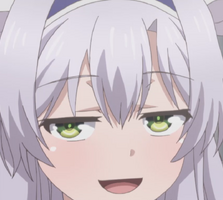

In [12]:
from IPython.display import Image

Image(filename=r'Character_Anime-Sistine~2.png', width=500)

## **Problema 3: Clustering — Segmentación y Gestión de Proveedores**

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

ruta_exel = r'C:\Users\Vanhertz\Downloads\datasets_evaluacion3.xlsx'
datos3 = pd.read_excel(ruta_exel,sheet_name=2, header=0)                 #recordar que el conteo en python comienza desde 0, por lo que la primera hoja es 0, la segunda es 1 y así sucesivamente

X3 = datos3.iloc[:,:].values                                             #para estos datos hay que estandarizar pues kmeans usa distancia euclideana.

array([[-0.9146292 ,  0.90445244, -1.19350514],
       [-0.78338846,  0.79002353, -0.12154756],
       [ 1.68190262, -0.01362448, -0.1262587 ],
       ...,
       [-0.01457717, -1.47490871,  1.39598596],
       [-1.0675156 ,  0.95626345, -1.44238572],
       [ 1.47298049, -0.15930384,  0.48063501]], shape=(1000, 3))

**a) Explique por que es un paso critico e indispensable normalizar o estandarizar las características
antes de entrenar el algoritmo K-Means en este contexto de cadena de suministro (pista: observar
las escalas y unidades de medida). Implemente la transformacion adecuada.**

In [15]:
datos3.describe()

,tiempo_entrega_dias,tasa_defectos_porcentaje,costo_flete_miles_usd
count,1000.000000,1000.000000,1000.000000
mean,13.308930,3.349062,6.914549
std,7.824504,1.660882,2.835707
min,3.000000,0.100000,1.200000
25%,6.563262,2.204823,4.515909
50%,11.522897,3.898403,6.994304
75%,18.471094,4.757326,9.205103
max,28.000000,5.600000,12.400000


Todo se debe a que Kmeans usa cálculo de distancias geométricas para encontrar centroides de grupo, al calcular distancias los valores mas grandes siempre serán los que tengan mas peso al tomar la decision el algoritmo, ignorando todas las demás que no tengan un valor significativo en relación a los datos mayores, para evitar esto es **obligatorio** estandarizar 
de la clase 21 tenemos:

"**NOTA: Cuando aplicamos K-means a datos del mundo real utilizando una métrica de distancia euclidiana, debemos asegurarnos de que las características se miden en la misma escala.**"

In [20]:
X3 = StandardScaler().fit_transform(X3)                                  #estandarizamos con lo mismo de clases anteriores, y conservamos el nombre de la variable
X3

array([[-0.9146292 ,  0.90445244, -1.19350514],
       [-0.78338846,  0.79002353, -0.12154756],
       [ 1.68190262, -0.01362448, -0.1262587 ],
       ...,
       [-0.01457717, -1.47490871,  1.39598596],
       [-1.0675156 ,  0.95626345, -1.44238572],
       [ 1.47298049, -0.15930384,  0.48063501]], shape=(1000, 3))

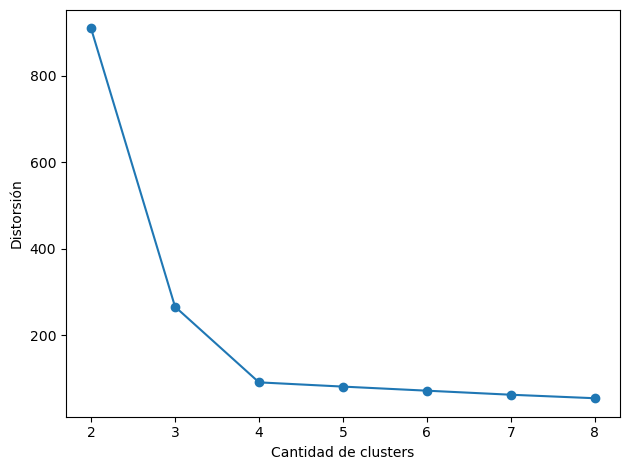

In [32]:
from sklearn.cluster import KMeans
#y_km = []  # Inicializamos un array vacío para un array de arrays /no era necesario pero lo dejamos para que quede claro que es un array de arrays
distortions = [] 
# Seteamos el algoritmo
for i in range(2, 9):  # probamos con 2 a 8 clusters **en Python, range() no incluye el límite superior**
    km = KMeans(n_clusters=i,init='k-means++', n_init=10, max_iter=300, tol=1e-04, random_state=0) 
    #y_km_train = km.fit_predict(X3)                 # Entrenamos el modelo y determinamos los grupos ("predecimos") -> extraído directamente de la clase 21 /no era nesesario
    #y_km.append(y_km_train)                   # Agregamos los resultados al array de arrays                                                                 /no era nesesario  
    km.fit(X3) 
    distortions.append(km.inertia_)           # Agregamos la distorsión al array de distorsiones
# gracias a lo anterior quedaría y_km como un array que entrega el conjunto necesario al usar [0,1,2,3,4,5,6] para los 7 conjuntos de clusters (insertar meme de gigachad)/no era nesesario
#
# y_km[0] K=2
# y_km[1] K=3
# y_km[2] K=4
# y_km[3] K=5
# y_km[4] K=6
# y_km[5] K=7
# y_km[6] K=8

plt.plot(range(2, 9), distortions, marker='o')
plt.xlabel('Cantidad de clusters')
plt.ylabel('Distorsión')
plt.tight_layout()
plt.show()

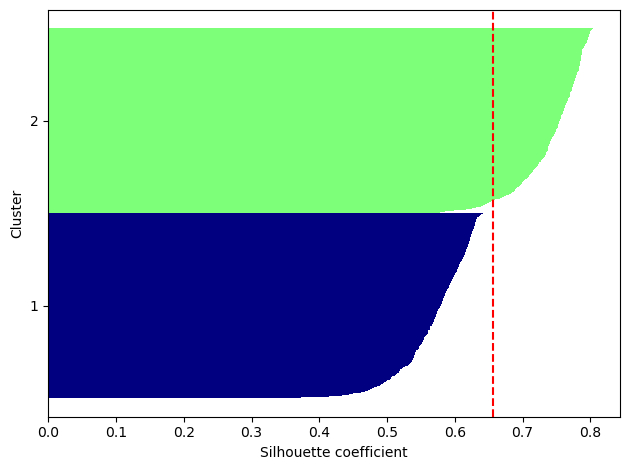

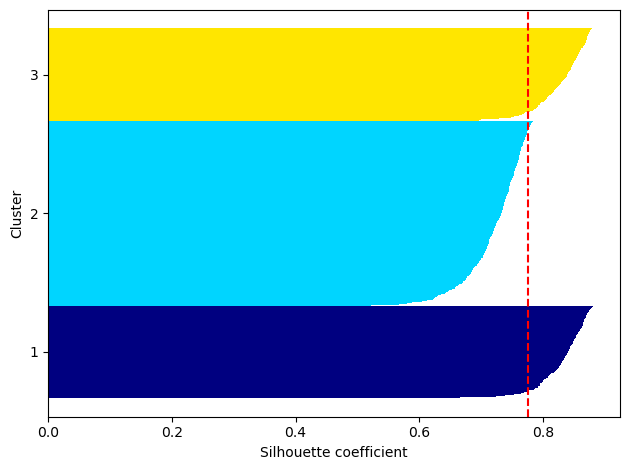

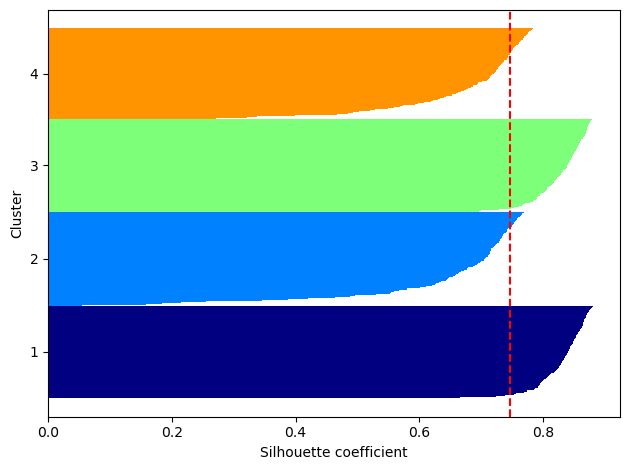

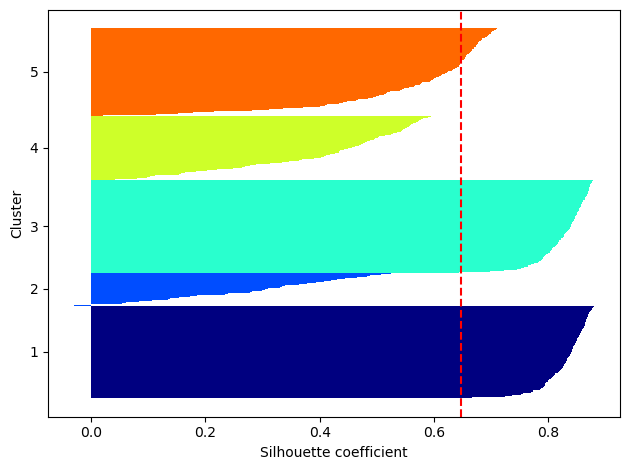

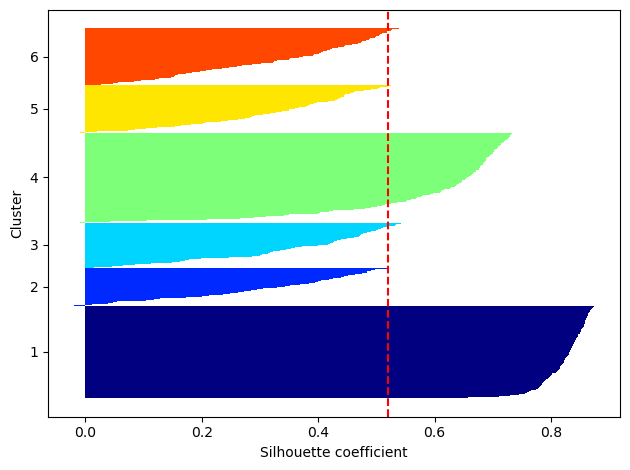

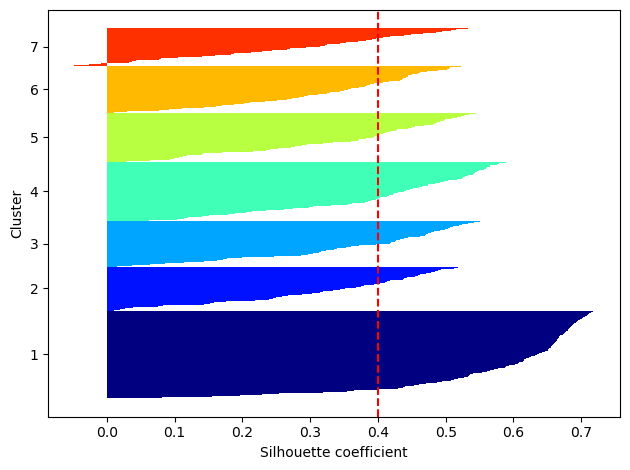

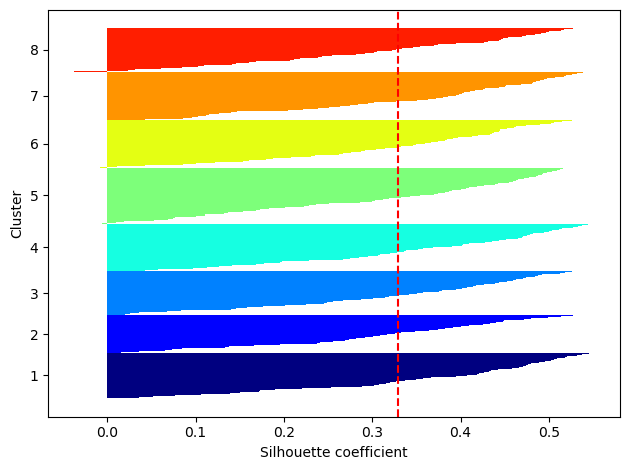

In [ ]:
from matplotlib import cm
from sklearn.metrics import silhouette_samples

y_km = []  # Inicializamos un array vacío para un array de arrays /no era necesario pero lo dejamos para que quede claro que es un array de arrays 
# Seteamos el algoritmo
for i in range(2, 9):  # probamos con 2 a 8 clusters **en Python, range() no incluye el límite superior**
    km = KMeans(n_clusters=i,init='k-means++', n_init=10, max_iter=300, tol=1e-04, random_state=0) 
    y_km_train = km.fit_predict(X3)                 # Entrenamos el modelo y determinamos los grupos ("predecimos") -> extraído directamente de la clase 21
    y_km.append(y_km_train)      
#arreglamos para que un for recorra el array de y_km[0] a y_km[6] y haga el grafico de silhouette para cada uno


for j in range (0,7):
    cluster_labels = np.unique(y_km[j])
    n_clusters = cluster_labels.shape[0]
    silhouette_vals = silhouette_samples(X3, y_km[j], metric='euclidean')
    y_ax_lower, y_ax_upper = 0, 0
    yticks = []
    for i, c in enumerate(cluster_labels):
        c_silhouette_vals = silhouette_vals[y_km[j] == c]
        c_silhouette_vals.sort()
        y_ax_upper += len(c_silhouette_vals)
        color = cm.jet(float(i) / n_clusters)
        plt.barh(range(y_ax_lower, y_ax_upper), c_silhouette_vals, height=1.0,edgecolor='none', color=color)

        yticks.append((y_ax_lower + y_ax_upper) / 2.)
        y_ax_lower += len(c_silhouette_vals)
    
    silhouette_avg = np.mean(silhouette_vals)
    plt.axvline(silhouette_avg, color="red", linestyle="--") 

    plt.yticks(yticks, cluster_labels + 1)
    plt.ylabel('Cluster')
    plt.xlabel('Silhouette coefficient')

    plt.tight_layout()
    plt.show()
    # viva el array de arrays jasjajdjadajsdsa 
    Image(filename=r'300px-Giga_Chad.jpg', width=500)